In [53]:
using PyPlot
using Statistics
using JLD2

### Define the system

In [54]:
# Nbr of particles
N_list = [6]
r = 10
d0_lb = 5e-10 # Minimum distance between the atoms (lower boundary) in m
λ = 421e-9
d0_lb = d0_lb / λ
window_t, window_var = 2, 4
threshold_box = 1e-5; # Time over which the boxes are computed

# Plots of the time evolution with dtmin

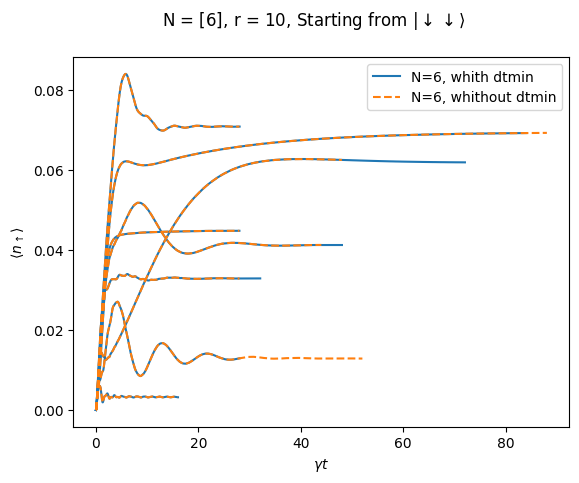

In [55]:
fig, ax = subplots()
list_t_N, popup_t_N, nbr_error_t_N, sol_t_N = [], [], [], []

for (i, N) in enumerate(N_list)
    line = []
    @load "solutions_with_dtmin/sol_N_$(N)_r_$(r).jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(nbr_error_t_N, nbr_error), push!(sol_t_N, sol_t)
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t[j], popup_t[j], label="N=$(N_list[i]), whith dtmin") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t[j], popup_t[j], color=line.get_color()) # marker="o", markersize=1,
            end
        end
    end
end

for (i, N) in enumerate(N_list)
    line = []
    @load "solutions_without_dtmin/sol_N_$(N)_r_$(r).jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    push!(list_t_N, list_t), push!(popup_t_N, popup_t), push!(nbr_error_t_N, nbr_error), push!(sol_t_N, sol_t)
    for j in 1:length(popup_t_N[i])
        if j ∉ nbr_error_t_N[i]
            if line == []
                line, = ax.plot(list_t[j], popup_t[j], label="N=$(N_list[i]), whithout dtmin", linestyle="--") # N_list[i] , marker="o", markersize=1,
            else
                ax.plot(list_t[j], popup_t[j], color=line.get_color(), linestyle="--") # marker="o", markersize=1,
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle  n_{\uparrow} \rangle $")
ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

# Timestep 

In [56]:
close("all")
fig, ax = subplots()
for i in 1:length(popup_t_N)
    line = []
    for j in 1:length(popup_t_N[i])
        T = list_t_N[i][j]
        if j == 1
            line, = ax.plot(T[1:end-1], T[2:end]-T[1:end-1])
        else
            ax.plot(T[1:end-1], T[2:end]-T[1:end-1], color=line.get_color())
        end
    end
end


ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\Delta T$")
ax.legend()
# pygui(false); gcf();
pygui(true); show()

PyCall.PyError: PyError ($(Expr(:escape, :(ccall(#= C:\Users\Joschka\.julia\packages\PyCall\1gn3u\src\pyfncall.jl:43 =# @pysym(:PyObject_Call), PyPtr, (PyPtr, PyPtr, PyPtr), o, pyargsptr, kw))))) <class 'AttributeError'>
AttributeError("type object 'FigureManagerBase' has no attribute '_owns_mainloop'")
  File "c:\users\joschka\appdata\local\programs\python\python313\Lib\site-packages\matplotlib\pyplot.py", line 614, in show
    return _get_backend_mod().show(*args, **kwargs)
           ~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "c:\users\joschka\appdata\local\programs\python\python313\Lib\site-packages\matplotlib\backend_bases.py", line 3550, in show
    cls.mainloop()
    ~~~~~~~~~~~~^^
  File "c:\users\joschka\appdata\local\programs\python\python313\Lib\site-packages\matplotlib\backends\_backend_tk.py", line 568, in start_main_loop
    if manager_class._owns_mainloop:
       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^


# Evolution of individual atoms

In [68]:
i, j = 1, 8
N = N_list[i]

close("all")
fig, ax = subplots()

line = []
@load "solutions_with_dtmin/sol_N_$(N)_r_$(r).jld2" sol_tasks
list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
if j ∉ nbr_error_t_N[i]
    ax.plot(list_t[j], popup_t[j], label="Sum")
    for n in 1:N
        ax.plot(list_t[j], real([sol_t[j][t][n] for t in 1:length(list_t[j])]), label="$n")
    end
    # ax.plot(list_t[j], sum([real([sol_t[j][t][m] for t in 1:length(list_t[j])]) for m = 1:N]), label="Test", linestyle="--")
end

line = []
@load "solutions_without_dtmin/sol_N_$(N)_r_$(r).jld2" sol_tasks
list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
if j ∉ nbr_error_t_N[i]
    ax.plot(list_t[j], popup_t[j], label="Sum whitout")
    for n in 1:N
        ax.plot(list_t[j], real([sol_t[j][t][n] for t in 1:length(list_t[j])]), label="$n, whitout", linestyle="--")
    end
    # ax.plot(list_t[j], sum([real([sol_t[j][t][m] for t in 1:length(list_t[j])]) for m = 1:N]), label="Test", linestyle="--")
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle n_{\uparrow} \rangle $")
# ax.set_ylim(-0.002, 0.005)
ax.legend()

suptitle("N = $N, r = $j, Starting from "*L"$|\downarrow \downarrow \rangle $")
# pygui(false); gcf();
pygui(true); show()

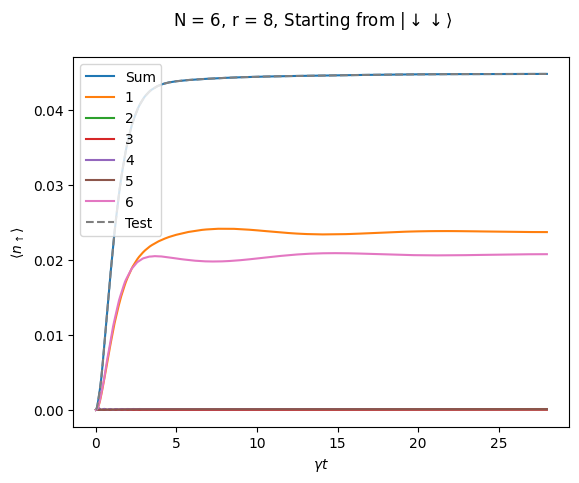

In [62]:
i, j = 1, 8
N = N_list[i]

close("all")
fig, ax = subplots()

line = []
@load "solutions_without_dtmin/sol_N_$(N)_r_$(r).jld2" sol_tasks
list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
if j ∉ nbr_error_t_N[i]
    ax.plot(list_t[j], popup_t[j], label="Sum")
    for n in 1:N
        ax.plot(list_t[j], real([sol_t[j][t][n] for t in 1:length(list_t[j])]), label="$n")
    end
    ax.plot(list_t[j], sum([real([sol_t[j][t][m] for t in 1:length(list_t[j])]) for m = 1:N]), label="Test", linestyle="--")
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle n_{\uparrow} \rangle $")
# ax.set_ylim(-0.002, 0.005)
ax.legend()

suptitle("N = $N, r = $j, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()

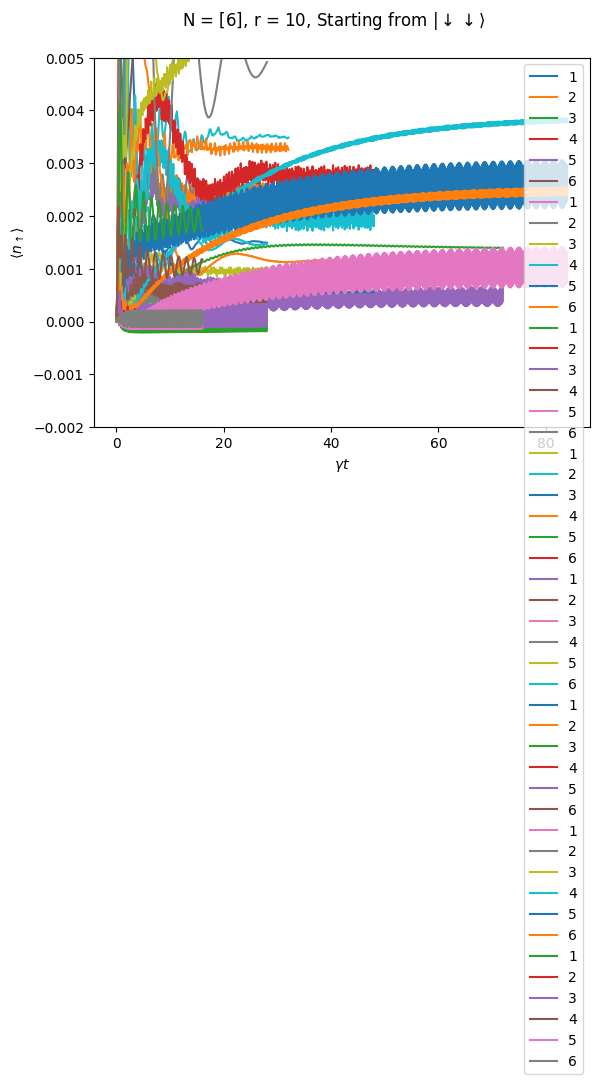

In [60]:
close("all")
fig, ax = subplots()

for (i, N) = enumerate([6])
    line = []
    @load "solutions_with_dtmin/sol_N_$(N)_r_$(r).jld2" sol_tasks
    list_t, popup_t, nbr_error, sol_t =  [vcat([s[i] for s in sol_tasks]...) for i = 1:4]
    for j = 1:10
        if j ∉ nbr_error_t_N[i]
            # ax.plot(list_t[j], popup_t[j], label="Sum")
            for n in 1:N
                ax.plot(list_t[j], real([sol_t[j][t][n] for t in 1:length(list_t[j])]), label="$n")
            end
        end
    end
end

ax.set_xlabel(L"$\gamma t$")
ax.set_ylabel(L"$\langle n_{\uparrow} \rangle $")
ax.set_ylim(-0.002, 0.005)
ax.legend()

suptitle("N = $N_list, r = $r, Starting from "*L"$|\downarrow \downarrow \rangle $")
pygui(false); gcf();
# pygui(true); show()